In [2]:
import sys
from pathlib import Path

Duong_Dan_Goc = Path(r"D:\HR Analytics")

sys.path.append(
    str(Duong_Dan_Goc / "python" / "src")
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from db import get_engine

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.base import clone

In [3]:
engine = get_engine()
query="""
select *
from dw.View_ML_NhanVien
order by NgayThang, MaNV
"""
df = pd.read_sql(query, engine)
df.head()

,MaNV,NgayThang,Nam,PhongBan,ChucDanh,CapBacCongViec,Tuoi,KhoangCachTuNha,SoLuongDuAn,SoGioTrungBinhThang,LamThemGio,DiemDanhGiaHieuSuat,DiemHaiLongCongViec,DiemHaiLongMoiTruong,ThuNhapThang,SoNamTaiCongTy,SoNamTuLanThangChucCuoi,DuocThangChucNamTruoc,TargetNghiViec
0,5,2018-01-01,2018,Information Technology,IT Support,2,41,15,5,194,False,3,2,3,16936000,7,7,False,0
1,6,2018-01-01,2018,Sales,Sales Supervisor,1,29,16,3,206,False,4,4,3,11779000,7,7,False,0
2,7,2018-01-01,2018,Operations,Operations Manager,2,28,36,1,177,False,2,2,3,15588000,4,4,False,1
3,8,2018-01-01,2018,Human Resources,C&B Specialist,3,35,3,4,240,True,3,1,4,33357000,6,6,False,0
4,10,2018-01-01,2018,Human Resources,C&B Specialist,2,38,35,3,166,False,4,2,2,15353000,4,4,False,0


In [4]:
featurea_So= [
    "Tuoi",
    "KhoangCachTuNha",
    "SoLuongDuAn",
    "SoGioTrungBinhThang",
    "DiemDanhGiaHieuSuat",
    "DiemHaiLongCongViec",
    "DiemHaiLongMoiTruong",
    "ThuNhapThang",
    "SoNamTaiCongTy",
    "SoNamTuLanThangChucCuoi",
    "CapBacCongViec"
]
features_Nhi_Phan = [
    "LamThemGio",
    "DuocThangChucNamTruoc"
]
features_danh_muc = [
    "PhongBan",
    "ChucDanh"
]
target = "TargetNghiViec"
feature_cot =( featurea_So + features_Nhi_Phan + features_danh_muc)


In [5]:
#Chia bộ dữ liệu train/valid/test
#Train: < 2023 | valid: 2024 | test: 2025

train = df[df["Nam"]==2023].copy()

valid = df[df["Nam"]==2024].copy()
test = df[df["Nam"]==2025].copy()

print("\ntrain")
print(train["Nam"].value_counts().sort_index())
print("\nvalid")
print(valid["Nam"].value_counts().sort_index())
print("\ntest")
print(test["Nam"].value_counts().sort_index())


train
Nam
2023    5195
Name: count, dtype: int64

valid
Nam
2024    5244
Name: count, dtype: int64

test
Nam
2025    4431
Name: count, dtype: int64


In [6]:
x_train = train[feature_cot].copy()
y_train = train[target].copy()

x_valid = valid[feature_cot].copy()
y_valid = valid[target].copy()

x_test = test[feature_cot].copy()
y_test = test[target].copy()

In [7]:
tree_tien_xu_ly = ColumnTransformer(
    transformers=[
        (
            "so",
            "passthrough",
            featurea_So
        ),

        (
            "nhi_phan",
            "passthrough",
            features_Nhi_Phan
        ),

        (
            "phan_loai",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            features_danh_muc
        )
    ]
)

In [8]:
X_train_tree = (
    tree_tien_xu_ly.fit_transform(
        x_train
    )
)

X_valid_tree = (
    tree_tien_xu_ly.transform(
        x_valid
    )
)

X_test_tree = (
    tree_tien_xu_ly.transform(
        x_test
    )
)

In [9]:
dt_baseline = DecisionTreeClassifier(
    random_state=42
)

dt_baseline.fit(
    X_train_tree,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [10]:
pred_dt_baseline = (
    dt_baseline.predict(
        X_valid_tree
    )
)

proba_dt_baseline = (
    dt_baseline.predict_proba(
        X_valid_tree
    )[:, 1]
)

In [11]:
print(
    classification_report(
        y_valid,
        pred_dt_baseline,
        digits=4
    )
)
print(
    confusion_matrix(
        y_valid,
        pred_dt_baseline
    )
)

              precision    recall  f1-score   support

           0     0.8577    0.8515    0.8546      4431
           1     0.2213    0.2300    0.2256       813

    accuracy                         0.7551      5244
   macro avg     0.5395    0.5408    0.5401      5244
weighted avg     0.7590    0.7551    0.7571      5244

[[3773  658]
 [ 626  187]]


In [12]:
dt_max_depth = [
    3,
    5,
    7,
    10,
    15,
    None
]

dt_min_leaf = [
    5,
    10,
    20,
    30
]

dt_min_split = [
    2,
    10,
    20
]

dt_class_weight = [
    None,
    "balanced"
]

In [13]:
ket_qua_dt = []

for depth in dt_max_depth:

    for leaf in dt_min_leaf:

        for split in dt_min_split:

            for cw in dt_class_weight:

                model = DecisionTreeClassifier(
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    min_samples_split=split,
                    class_weight=cw,
                    random_state=42
                )

                model.fit(
                    X_train_tree,
                    y_train
                )

                proba = model.predict_proba(
                    X_valid_tree
                )[:, 1]

                pred = (
                    proba >= 0.5
                ).astype(int)

                ket_qua_dt.append({
                    "MaxDepth": depth,
                    "MinLeaf": leaf,
                    "MinSplit": split,
                    "ClassWeight": str(cw),

                    "Accuracy":
                        accuracy_score(
                            y_valid,
                            pred
                        ),

                    "Precision":
                        precision_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "Recall":
                        recall_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "F1":
                        f1_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "ROC_AUC":
                        roc_auc_score(
                            y_valid,
                            proba
                        ),

                    "PR_AUC":
                        average_precision_score(
                            y_valid,
                            proba
                        )
                })

In [14]:
ket_qua_dt = pd.DataFrame(
    ket_qua_dt
)
ket_qua_dt.sort_values(
    [
        "F1",
        "Recall"
    ],
    ascending=False
).head(20)

,MaxDepth,MinLeaf,MinSplit,ClassWeight,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
19,3.0,30,2,balanced,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
21,3.0,30,10,balanced,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
23,3.0,30,20,balanced,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
37,5.0,20,2,balanced,0.688215,0.265411,0.571956,0.362573,0.674634,0.277890
39,5.0,20,10,balanced,0.688215,0.265411,0.571956,0.362573,0.674634,0.277890
41,5.0,20,20,balanced,0.688215,0.265411,0.571956,0.362573,0.674634,0.277890
31,5.0,10,2,balanced,0.676773,0.261105,0.592866,0.362542,0.671074,0.276711
33,5.0,10,10,balanced,0.676773,0.261105,0.592866,0.362542,0.671074,0.276711
35,5.0,10,20,balanced,0.676773,0.261105,0.592866,0.362542,0.671074,0.276711
1,3.0,5,2,balanced,0.729977,0.285714,0.494465,0.362162,0.677079,0.261104


In [15]:
threshold_values = np.arange(
    0.10,
    0.71,
    0.02
)
ket_qua_dt_threshold = []

for depth in dt_max_depth:

    for leaf in dt_min_leaf:

        for split in dt_min_split:

            for cw in dt_class_weight:

                model = DecisionTreeClassifier(
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    min_samples_split=split,
                    class_weight=cw,
                    random_state=42
                )

                model.fit(
                    X_train_tree,
                    y_train
                )

                proba = model.predict_proba(
                    X_valid_tree
                )[:, 1]

                roc = roc_auc_score(
                    y_valid,
                    proba
                )

                pr = average_precision_score(
                    y_valid,
                    proba
                )

                for threshold in threshold_values:

                    pred = (
                        proba >= threshold
                    ).astype(int)

                    ket_qua_dt_threshold.append({
                        "MaxDepth": depth,
                        "MinLeaf": leaf,
                        "MinSplit": split,
                        "ClassWeight": str(cw),

                        "Threshold":
                            round(
                                threshold,
                                2
                            ),

                        "Accuracy":
                            accuracy_score(
                                y_valid,
                                pred
                            ),

                        "Precision":
                            precision_score(
                                y_valid,
                                pred,
                                zero_division=0
                            ),

                        "Recall":
                            recall_score(
                                y_valid,
                                pred,
                                zero_division=0
                            ),

                        "F1":
                            f1_score(
                                y_valid,
                                pred,
                                zero_division=0
                            ),

                        "ROC_AUC": roc,
                        "PR_AUC": pr
                    })

In [16]:
ket_qua_dt_threshold = pd.DataFrame(
    ket_qua_dt_threshold
)

In [17]:
(
    ket_qua_dt_threshold[
        ket_qua_dt_threshold[
            "Recall"
        ] >= 0.50
    ]
    .sort_values(
        [
            "F1",
            "Precision"
        ],
        ascending=False
    )
    .head(20)
)

,MaxDepth,MinLeaf,MinSplit,ClassWeight,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
748,5.0,5,2,None,0.18,0.693555,0.268917,0.568266,0.365073,0.678763,0.272976
810,5.0,5,10,None,0.18,0.693555,0.268917,0.568266,0.365073,0.678763,0.272976
872,5.0,5,20,None,0.18,0.693555,0.268917,0.568266,0.365073,0.678763,0.272976
561,3.0,30,2,None,0.16,0.726354,0.284924,0.506765,0.364763,0.682217,0.267969
562,3.0,30,2,None,0.18,0.726354,0.284924,0.506765,0.364763,0.682217,0.267969
563,3.0,30,2,None,0.20,0.726354,0.284924,0.506765,0.364763,0.682217,0.267969
608,3.0,30,2,balanced,0.48,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
609,3.0,30,2,balanced,0.50,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
610,3.0,30,2,balanced,0.52,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478
611,3.0,30,2,balanced,0.54,0.726354,0.284924,0.506765,0.364763,0.684286,0.268478


In [18]:
best_dt_row = (
    ket_qua_dt_threshold
    .sort_values(
        [
            "F1",
            "Recall"
        ],
        ascending=False
    )
    .iloc[0]
)

best_dt_row

MaxDepth            5.0
MinLeaf               5
MinSplit              2
ClassWeight        None
Threshold          0.18
Accuracy       0.693555
Precision      0.268917
Recall         0.568266
F1             0.365073
ROC_AUC        0.678763
PR_AUC         0.272976
Name: 748, dtype: object

In [19]:
BEST_DT_DEPTH = (
    None
    if pd.isna(
        best_dt_row["MaxDepth"]
    )
    else int(
        best_dt_row["MaxDepth"]
    )
)

BEST_DT_LEAF = int(
    best_dt_row["MinLeaf"]
)

BEST_DT_SPLIT = int(
    best_dt_row["MinSplit"]
)

BEST_DT_CW = (
    None
    if best_dt_row["ClassWeight"] == "None"
    else "balanced"
)

BEST_DT_THRESHOLD = float(
    best_dt_row["Threshold"]
)

print(
    "Depth:",
    BEST_DT_DEPTH
)

print(
    "Leaf:",
    BEST_DT_LEAF
)

print(
    "Split:",
    BEST_DT_SPLIT
)

print(
    "ClassWeight:",
    BEST_DT_CW
)

print(
    "Threshold:",
    BEST_DT_THRESHOLD
)

Depth: 5
Leaf: 5
Split: 2
ClassWeight: None
Threshold: 0.18


In [20]:
final_train = df[
    df["Nam"] == 2024
].copy()

final_test = df[
    df["Nam"] == 2025
].copy()

In [21]:
X_final_train = final_train[
    feature_cot
].copy()

y_final_train = final_train[
    target
].copy()

X_final_test = final_test[
    feature_cot
].copy()

y_final_test = final_test[
    target
].copy()

In [22]:
from sklearn.base import clone

final_tree_preprocessor = clone(
    tree_tien_xu_ly
)

X_final_train_tree = (
    final_tree_preprocessor.fit_transform(
        X_final_train
    )
)

X_final_test_tree = (
    final_tree_preprocessor.transform(
        X_final_test
    )
)

In [23]:
print(
    "Final Train:",
    X_final_train_tree.shape
)

print(
    "Final Test:",
    X_final_test_tree.shape
)

Final Train: (5244, 44)
Final Test: (4431, 44)


In [24]:
final_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=2,
    class_weight=None,
    random_state=42
)

final_dt.fit(
    X_final_train_tree,
    y_final_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [25]:
proba_dt_test = (
    final_dt.predict_proba(
        X_final_test_tree
    )[:, 1]
)

pred_dt_test = (
    proba_dt_test >= 0.18
).astype(int)

In [26]:
print(
    classification_report(
        y_final_test,
        pred_dt_test,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9075    0.6929    0.7858      3767
           1     0.2559    0.5994    0.3587       664

    accuracy                         0.6789      4431
   macro avg     0.5817    0.6461    0.5723      4431
weighted avg     0.8099    0.6789    0.7218      4431



In [27]:
cm_dt = confusion_matrix(
    y_final_test,
    pred_dt_test
)

print(cm_dt)

[[2610 1157]
 [ 266  398]]


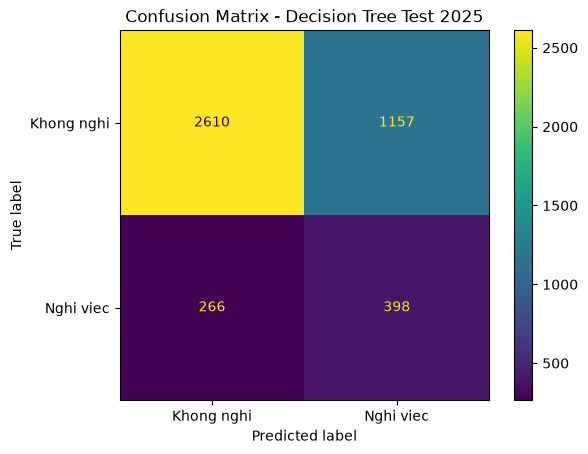

In [28]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=[
        "Khong nghi",
        "Nghi viec"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - Decision Tree Test 2025"
)

plt.show()

In [29]:
ket_qua_dt_test = {
    "Accuracy": accuracy_score(
        y_final_test,
        pred_dt_test
    ),

    "Precision": precision_score(
        y_final_test,
        pred_dt_test,
        zero_division=0
    ),

    "Recall": recall_score(
        y_final_test,
        pred_dt_test,
        zero_division=0
    ),

    "F1": f1_score(
        y_final_test,
        pred_dt_test,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_final_test,
        proba_dt_test
    ),

    "PR_AUC": average_precision_score(
        y_final_test,
        proba_dt_test
    )
}

pd.Series(
    ket_qua_dt_test
).round(4)

Accuracy     0.6789
Precision    0.2559
Recall       0.5994
F1           0.3587
ROC_AUC      0.6757
PR_AUC       0.2583
dtype: float64

In [30]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(
    X_train_tree,
    y_train
)

pred_rf_baseline = rf_baseline.predict(
    X_valid_tree
)

proba_rf_baseline = (
    rf_baseline.predict_proba(
        X_valid_tree
    )[:, 1]
)

print(
    classification_report(
        y_valid,
        pred_rf_baseline,
        digits=4
    )
)

print(
    confusion_matrix(
        y_valid,
        pred_rf_baseline
    )
)

              precision    recall  f1-score   support

           0     0.8472    0.9957    0.9154      4431
           1     0.4722    0.0209    0.0400       813

    accuracy                         0.8446      5244
   macro avg     0.6597    0.5083    0.4777      5244
weighted avg     0.7890    0.8446    0.7797      5244

[[4412   19]
 [ 796   17]]


In [31]:
rf_n_estimators = [
    100,
    200,
    300
]

rf_max_depth = [
    5,
    10,
    15,
    None
]

rf_min_leaf = [
    2,
    5,
    10
]

rf_class_weight = [
    None,
    "balanced",
    "balanced_subsample"
]

In [32]:
ket_qua_rf = []

for n_tree in rf_n_estimators:

    for depth in rf_max_depth:

        for leaf in rf_min_leaf:

            for cw in rf_class_weight:

                model = RandomForestClassifier(
                    n_estimators=n_tree,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    class_weight=cw,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_tree,
                    y_train
                )

                proba = model.predict_proba(
                    X_valid_tree
                )[:, 1]

                pred = (
                    proba >= 0.5
                ).astype(int)

                ket_qua_rf.append({
                    "NTrees": n_tree,
                    "MaxDepth": depth,
                    "MinLeaf": leaf,
                    "ClassWeight": str(cw),

                    "Accuracy":
                        accuracy_score(
                            y_valid,
                            pred
                        ),

                    "Precision":
                        precision_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "Recall":
                        recall_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "F1":
                        f1_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                    "ROC_AUC":
                        roc_auc_score(
                            y_valid,
                            proba
                        ),

                    "PR_AUC":
                        average_precision_score(
                            y_valid,
                            proba
                        )
                })

In [33]:
ket_qua_rf = pd.DataFrame(
    ket_qua_rf
)

ket_qua_rf.sort_values(
    ["F1", "Recall"],
    ascending=False
).head(20)

,NTrees,MaxDepth,MinLeaf,ClassWeight,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
7,100,5.0,10,balanced,0.704615,0.283019,0.590406,0.382623,0.706033,0.317218
79,300,5.0,10,balanced,0.702708,0.281871,0.592866,0.382085,0.707208,0.320586
1,100,5.0,2,balanced,0.704996,0.282840,0.587946,0.381942,0.704807,0.315638
76,300,5.0,5,balanced,0.704615,0.282506,0.587946,0.381637,0.706418,0.316636
40,200,5.0,5,balanced,0.701564,0.280630,0.591636,0.380689,0.705708,0.315020
2,100,5.0,2,balanced_subsample,0.719298,0.289187,0.555966,0.380471,0.706215,0.316556
73,300,5.0,2,balanced,0.703661,0.281416,0.586716,0.380383,0.706140,0.321059
80,300,5.0,10,balanced_subsample,0.713387,0.285714,0.565806,0.379695,0.706048,0.314715
43,200,5.0,10,balanced,0.700229,0.279489,0.591636,0.379637,0.706647,0.317407
70,200,NaN,10,balanced,0.729405,0.294437,0.533825,0.379537,0.705947,0.314523


In [34]:
threshold_values_rf = np.arange(
    0.20,
    0.71,
    0.02
)

In [35]:
ket_qua_rf_threshold = []

for n_tree in rf_n_estimators:

    for depth in rf_max_depth:

        for leaf in rf_min_leaf:

            for cw in rf_class_weight:

                model = RandomForestClassifier(
                    n_estimators=n_tree,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    class_weight=cw,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_tree,
                    y_train
                )

                proba = model.predict_proba(
                    X_valid_tree
                )[:, 1]

                roc = roc_auc_score(
                    y_valid,
                    proba
                )

                pr = average_precision_score(
                    y_valid,
                    proba
                )

                for threshold in threshold_values_rf:

                    pred = (
                        proba >= threshold
                    ).astype(int)

                    ket_qua_rf_threshold.append({
                        "NTrees": n_tree,
                        "MaxDepth": depth,
                        "MinLeaf": leaf,
                        "ClassWeight": str(cw),
                        "Threshold": round(
                            threshold, 2
                        ),

                        "Accuracy": accuracy_score(
                            y_valid,
                            pred
                        ),

                        "Precision": precision_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                        "Recall": recall_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                        "F1": f1_score(
                            y_valid,
                            pred,
                            zero_division=0
                        ),

                        "ROC_AUC": roc,
                        "PR_AUC": pr
                    })

In [36]:
ket_qua_rf_threshold = pd.DataFrame(
    ket_qua_rf_threshold
)

In [37]:
ket_qua_rf_threshold.sort_values(
    ["F1", "Recall"],
    ascending=False
).head(20)

,NTrees,MaxDepth,MinLeaf,ClassWeight,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
198,100,5.0,10,balanced,0.52,0.735889,0.301113,0.532595,0.384718,0.706033,0.317218
546,100,15.0,5,None,0.20,0.738940,0.302837,0.525215,0.384166,0.703909,0.312020
2070,300,5.0,10,balanced,0.52,0.734363,0.299724,0.533825,0.383901,0.707208,0.320586
1134,200,5.0,10,balanced,0.52,0.734172,0.299240,0.532595,0.383186,0.706647,0.317407
936,200,5.0,2,None,0.20,0.760107,0.318367,0.479705,0.382728,0.707360,0.323872
390,100,10.0,10,None,0.20,0.744661,0.306047,0.510455,0.382665,0.705791,0.318463
197,100,5.0,10,balanced,0.50,0.704615,0.283019,0.590406,0.382623,0.706033,0.317218
1602,200,15.0,10,balanced,0.52,0.750953,0.310530,0.496925,0.382214,0.705051,0.314172
1482,200,15.0,5,None,0.20,0.740465,0.302878,0.517835,0.382206,0.706536,0.316323
2069,300,5.0,10,balanced,0.50,0.702708,0.281871,0.592866,0.382085,0.707208,0.320586


In [38]:
(
    ket_qua_rf_threshold[
        ket_qua_rf_threshold["Recall"] >= 0.50
    ]
    .sort_values(
        ["F1", "Precision"],
        ascending=False
    )
    .head(20)
)

,NTrees,MaxDepth,MinLeaf,ClassWeight,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
198,100,5.0,10,balanced,0.52,0.735889,0.301113,0.532595,0.384718,0.706033,0.317218
546,100,15.0,5,None,0.20,0.738940,0.302837,0.525215,0.384166,0.703909,0.312020
2070,300,5.0,10,balanced,0.52,0.734363,0.299724,0.533825,0.383901,0.707208,0.320586
1134,200,5.0,10,balanced,0.52,0.734172,0.299240,0.532595,0.383186,0.706647,0.317407
390,100,10.0,10,None,0.20,0.744661,0.306047,0.510455,0.382665,0.705791,0.318463
197,100,5.0,10,balanced,0.50,0.704615,0.283019,0.590406,0.382623,0.706033,0.317218
1482,200,15.0,5,None,0.20,0.740465,0.302878,0.517835,0.382206,0.706536,0.316323
2069,300,5.0,10,balanced,0.50,0.702708,0.281871,0.592866,0.382085,0.707208,0.320586
41,100,5.0,2,balanced,0.50,0.704996,0.282840,0.587946,0.381942,0.704807,0.315638
624,100,15.0,10,None,0.20,0.738940,0.301712,0.520295,0.381941,0.702141,0.320835


In [39]:
(
    ket_qua_rf_threshold[
        ket_qua_rf_threshold["Recall"] >= 0.60
    ]
    .sort_values(
        ["F1", "Precision"],
        ascending=False
    )
    .head(20)
)

,NTrees,MaxDepth,MinLeaf,ClassWeight,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2559,300,15.0,10,balanced_subsample,0.42,0.690122,0.275194,0.611316,0.379534,0.706459,0.312253
921,100,NaN,10,balanced_subsample,0.42,0.691266,0.275362,0.607626,0.378980,0.705899,0.311509
1623,200,15.0,10,balanced_subsample,0.42,0.693364,0.276056,0.602706,0.378671,0.706847,0.312587
2168,300,10.0,2,balanced_subsample,0.40,0.684211,0.272039,0.618696,0.377911,0.698420,0.299012
1857,200,NaN,10,balanced_subsample,0.42,0.692410,0.275028,0.601476,0.377460,0.707146,0.311422
2769,300,NaN,10,balanced,0.46,0.677727,0.269332,0.629766,0.377303,0.706714,0.314687
2792,300,NaN,10,balanced_subsample,0.40,0.669336,0.266362,0.645756,0.377155,0.706425,0.310867
1938,300,5.0,2,balanced_subsample,0.48,0.676964,0.268766,0.629766,0.376748,0.707538,0.314738
1002,200,5.0,2,balanced_subsample,0.48,0.678680,0.269312,0.626076,0.376619,0.707379,0.315448
920,100,NaN,10,balanced_subsample,0.40,0.663616,0.263785,0.653137,0.375796,0.705899,0.311509


In [40]:
best_rf_row = (
    ket_qua_rf_threshold
    .sort_values(
        ["F1", "Recall"],
        ascending=False
    )
    .iloc[0]
)

best_rf_row

NTrees              100
MaxDepth            5.0
MinLeaf              10
ClassWeight    balanced
Threshold          0.52
Accuracy       0.735889
Precision      0.301113
Recall         0.532595
F1             0.384718
ROC_AUC        0.706033
PR_AUC         0.317218
Name: 198, dtype: object

In [41]:
BEST_RF_N = int(
    best_rf_row["NTrees"]
)

BEST_RF_DEPTH = (
    None
    if pd.isna(
        best_rf_row["MaxDepth"]
    )
    else int(
        best_rf_row["MaxDepth"]
    )
)

BEST_RF_LEAF = int(
    best_rf_row["MinLeaf"]
)

BEST_RF_CW = best_rf_row[
    "ClassWeight"
]

if BEST_RF_CW == "None":
    BEST_RF_CW = None

BEST_RF_THRESHOLD = float(
    best_rf_row["Threshold"]
)

print("N trees:", BEST_RF_N)
print("Depth:", BEST_RF_DEPTH)
print("Min leaf:", BEST_RF_LEAF)
print("ClassWeight:", BEST_RF_CW)
print("Threshold:", BEST_RF_THRESHOLD)

N trees: 100
Depth: 5
Min leaf: 10
ClassWeight: balanced
Threshold: 0.52


In [42]:
final_rf = RandomForestClassifier(
    n_estimators=BEST_RF_N,
    max_depth=BEST_RF_DEPTH,
    min_samples_leaf=BEST_RF_LEAF,
    class_weight=BEST_RF_CW,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    X_final_train_tree,
    y_final_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [43]:
proba_rf_test = (
    final_rf.predict_proba(
        X_final_test_tree
    )[:, 1]
)
pred_rf_test = (
    proba_rf_test
    >= BEST_RF_THRESHOLD
).astype(int)

In [44]:
print(
    classification_report(
        y_final_test,
        pred_rf_test,
        digits=4
    )
)
cm_rf = confusion_matrix(
    y_final_test,
    pred_rf_test
)

print(cm_rf)

              precision    recall  f1-score   support

           0     0.9019    0.7491    0.8184      3767
           1     0.2742    0.5377    0.3632       664

    accuracy                         0.7174      4431
   macro avg     0.5880    0.6434    0.5908      4431
weighted avg     0.8078    0.7174    0.7502      4431

[[2822  945]
 [ 307  357]]


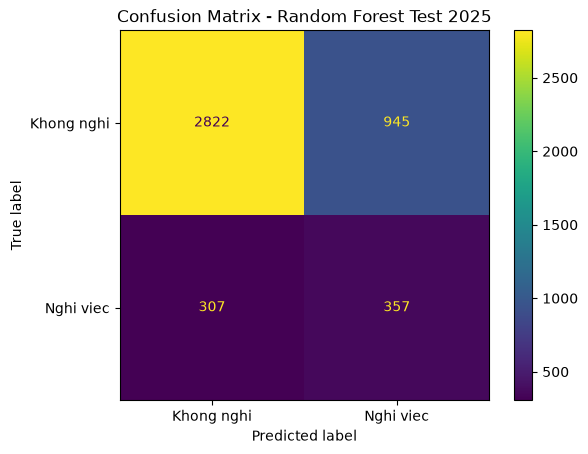

In [45]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "Khong nghi",
        "Nghi viec"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - Random Forest Test 2025"
)

plt.show()

In [46]:
ket_qua_rf_test = {
    "Accuracy": accuracy_score(
        y_final_test,
        pred_rf_test
    ),

    "Precision": precision_score(
        y_final_test,
        pred_rf_test,
        zero_division=0
    ),

    "Recall": recall_score(
        y_final_test,
        pred_rf_test,
        zero_division=0
    ),

    "F1": f1_score(
        y_final_test,
        pred_rf_test,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_final_test,
        proba_rf_test
    ),

    "PR_AUC": average_precision_score(
        y_final_test,
        proba_rf_test
    )
}

pd.Series(
    ket_qua_rf_test
).round(4)

Accuracy     0.7174
Precision    0.2742
Recall       0.5377
F1           0.3632
ROC_AUC      0.7067
PR_AUC       0.3218
dtype: float64

In [47]:
so_sanh_mo_hinh = pd.DataFrame([
    {
        "MoHinh": "KNN",
        "Accuracy": 0.6804,
        "Precision": 0.2453,
        "Recall": 0.5452,
        "F1": 0.3383,
        "ROC_AUC": 0.6643,
        "PR_AUC": 0.2577
    },

    {
        "MoHinh": "Decision Tree",
        "Accuracy": 0.6789,
        "Precision": 0.2559,
        "Recall": 0.5994,
        "F1": 0.3587,
        "ROC_AUC": 0.6757,
        "PR_AUC": 0.2583
    },

    {
        "MoHinh": "Random Forest",
        **ket_qua_rf_test
    }
])

so_sanh_mo_hinh.round(4)

,MoHinh,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,KNN,0.6804,0.2453,0.5452,0.3383,0.6643,0.2577
1,Decision Tree,0.6789,0.2559,0.5994,0.3587,0.6757,0.2583
2,Random Forest,0.7174,0.2742,0.5377,0.3632,0.7067,0.3218
